# 06a — Compare Uncertainty Results to Pareto Members

**Purpose:** Connect the PyCAP uncertainty work to the existing Pareto/MOU results from the Little Plover River project.

This notebook uses the Pareto artifacts copied into:

```text
data/raw/lpr_pycap/pareto/
```

and compares them with the uncertainty results created in earlier notebooks:

```text
04_pycap_parameter_perturbation.ipynb
05a_pycap_parameter_perturbation_selected_wells.ipynb
05b_pycap_monte_carlo_uncertainty.ipynb
```

## Main questions

1. What Pareto/MOU output files do we have?
2. What columns/objectives are inside the Pareto summary files?
3. How do the baseline, `T -10%`, and `T +10% Pareto fronts compare?
4. Can we use the saved Pareto-member pumping table to reevaluate Pareto members under PyCAP uncertainty scenarios?
5. Which Pareto members are robust or fragile with respect to streamflow/depletion constraints?

## Conceptual reminder

A Pareto front is the set of **nondominated** tradeoff solutions.

For example, if we want to:

- maximize pumping, and
- minimize stream depletion,

then a member is Pareto-optimal if there is no other member that has **more pumping** and **less depletion** at the same time.

The existing MOU results are optimized Pareto results. This notebook does not rerun PEST++-MOU. It imports and analyzes the existing artifacts.


## 1. Imports and project-root setup

In [135]:
from pathlib import Path
import os
import sys
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

def find_project_root(start=None):
    """Find the repository root by looking for common project marker files."""
    start = Path.cwd() if start is None else Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / ".git").exists() and (candidate / "environment.yml").exists():
            return candidate

    for candidate in candidates:
        if (candidate / "models").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Try opening Jupyter from the Modeling-Uncertainties repo root."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Current working directory: {Path.cwd()}")
print(f"Python executable: {sys.executable}")


Project root: /workspaces/Modeling-Uncertainties
Current working directory: /workspaces/Modeling-Uncertainties
Python executable: /opt/conda/envs/gw_uncertainty/bin/python


## 2. Define paths

This notebook reads raw Pareto artifacts and writes processed comparison tables/figures.


In [136]:
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

PYCAP_RAW_DIR = DATA_DIR / "raw" / "lpr_pycap"
PYCAP_BASE_DIR = PYCAP_RAW_DIR / "pycap_base"
PYCAP_BASE_OUTPUT_DIR = PYCAP_BASE_DIR / "output"
PARETO_RAW_DIR = PYCAP_RAW_DIR / "pareto"
PARETO_DEPLETION_DIR = PARETO_RAW_DIR / "depletion_q"
PARETO_FISH_DOLLARS_DIR = PARETO_RAW_DIR / "fish_dollars"

PYCAP_RESULTS_DIR = RESULTS_DIR / "pycap_runs"
PARAM_PERTURB_TABLES_DIR = PYCAP_RESULTS_DIR / "parameter_perturbation" / "tables"
MC_TABLES_DIR = PYCAP_RESULTS_DIR / "monte_carlo_uncertainty" / "tables"
SELECTED_WELL_TABLES_DIR = PYCAP_RESULTS_DIR / "selected_wells_perturbation" / "tables"

NOTEBOOK_OUT_DIR = PYCAP_RESULTS_DIR / "pareto_uncertainty_comparison"
TABLES_DIR = NOTEBOOK_OUT_DIR / "tables"
FIGURES_DIR = NOTEBOOK_OUT_DIR / "figures"

for folder in [NOTEBOOK_OUT_DIR, TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PYCAP_RUN_NAME = "LPR_Redux"
PYCAP_YAML_PATH = PYCAP_BASE_DIR / f"{PYCAP_RUN_NAME}.yml"

BASELINE_HOOVER_STREAMFLOW_CFS = 8.6
PUBLIC_RIGHTS_FLOW_CFS = 6.8
PRF_ALLOWED_DEPLETION_CFS = BASELINE_HOOVER_STREAMFLOW_CFS - PUBLIC_RIGHTS_FLOW_CFS

print(f"Pareto raw folder: {PARETO_RAW_DIR.relative_to(PROJECT_ROOT)}")
print(f"Output folder:     {NOTEBOOK_OUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"PRF allowed depletion: {PRF_ALLOWED_DEPLETION_CFS:.3f} cfs")


Pareto raw folder: data/raw/lpr_pycap/pareto
Output folder:     results/pycap_runs/pareto_uncertainty_comparison
PRF allowed depletion: 1.800 cfs


## 3. Confirm Pareto artifacts exist

In [137]:
required_paths = {
    "pareto_raw_dir": PARETO_RAW_DIR,
    "depletion_q_dir": PARETO_DEPLETION_DIR,
    "fish_dollars_dir": PARETO_FISH_DOLLARS_DIR,
    "pareto_members_q": PARETO_DEPLETION_DIR / "depletion_q_baseline_0.0_1.0_0.2_pareto_members_q.csv",
    "pycap_yaml": PYCAP_YAML_PATH,
}

path_check = pd.DataFrame(
    [
        {
            "item": name,
            "relative_path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_MB": round(path.stat().st_size / 1_000_000, 3) if path.exists() and path.is_file() else None,
        }
        for name, path in required_paths.items()
    ]
)

path_check


,item,relative_path,exists,size_MB
0,pareto_raw_dir,data/raw/lpr_pycap/pareto,True,NaN
1,depletion_q_dir,data/raw/lpr_pycap/pareto/depletion_q,True,NaN
2,fish_dollars_dir,data/raw/lpr_pycap/pareto/fish_dollars,True,NaN
3,pareto_members_q,data/raw/lpr_pycap/pareto/depletion_q/depletio...,True,0.363
4,pycap_yaml,data/raw/lpr_pycap/pycap_base/LPR_Redux.yml,True,0.108


In [138]:
missing = path_check.loc[~path_check["exists"], "relative_path"].tolist()

if missing:
    raise FileNotFoundError(f"Missing required Pareto artifacts: {missing}")

print("Required Pareto artifacts were found.")


Required Pareto artifacts were found.


## 4. Inventory Pareto artifact files

In [139]:
pareto_files = sorted([p for p in PARETO_RAW_DIR.rglob("*") if p.is_file()])

pareto_file_inventory = pd.DataFrame(
    [
        {
            "file": p.name,
            "relative_path": str(p.relative_to(PROJECT_ROOT)),
            "family": p.parent.name,
            "suffix": "".join(p.suffixes),
            "size_MB": round(p.stat().st_size / 1_000_000, 3),
        }
        for p in pareto_files
    ]
)

pareto_file_inventory_path = TABLES_DIR / "pareto_file_inventory.csv"
pareto_file_inventory.to_csv(pareto_file_inventory_path, index=False)

print(f"Saved: {pareto_file_inventory_path.relative_to(PROJECT_ROOT)}")
pareto_file_inventory


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_file_inventory.csv


,file,relative_path,family,suffix,size_MB
0,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.archi...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.archive.summary.csv.zip,0.065
1,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.summa...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.summary.csv.zip,0.067
2,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.trimm...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.trimmed.archive.summary.csv.zip,0.049
3,depletion_q_Tmin10per_0.0_1.0_0.2.rec,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.rec,0.469
4,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.arch...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.archive.summary.csv.zip,0.060
5,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.summ...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.summary.csv.zip,0.067
6,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.trim...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.trimmed.archive.summary.csv.zip,0.047
7,depletion_q_Tplus10per_0.0_1.0_0.2.rec,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.rec,0.469
8,depletion_q_baseline_0.0_1.0_0.2.pareto.archiv...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.archive.summary.csv.zip,0.057
9,depletion_q_baseline_0.0_1.0_0.2.pareto.summar...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,depletion_q,.0_1.0_0.2.pareto.summary.csv.zip,0.067


## 5. Helper functions for reading Pareto summary files

The Pareto summaries are stored as zipped CSV files. These helpers read them and add metadata from the file name.


In [140]:
def read_zipped_csv(path):
    """Read a zipped CSV file into a DataFrame."""
    path = Path(path)

    if path.suffix.lower() != ".zip":
        return pd.read_csv(path)

    with zipfile.ZipFile(path, "r") as zf:
        csv_names = [name for name in zf.namelist() if name.lower().endswith(".csv")]

        if len(csv_names) == 0:
            raise FileNotFoundError(f"No CSV file found inside zip: {path}")

        if len(csv_names) > 1:
            print(f"Multiple CSV files found in {path.name}; reading first one: {csv_names[0]}")

        with zf.open(csv_names[0]) as f:
            return pd.read_csv(f)


def classify_run_name(filename):
    """Classify baseline/T-/T+ and table type from a Pareto artifact filename."""
    text = filename.lower()

    if "baseline" in text:
        run_case = "baseline"
    elif "tmin10per" in text:
        run_case = "T_minus_10_percent"
    elif "tplus10per" in text:
        run_case = "T_plus_10_percent"
    else:
        run_case = "unknown"

    if "trimmed.archive.summary" in text:
        table_type = "trimmed_archive_summary"
    elif "archive.summary" in text:
        table_type = "archive_summary"
    elif "pareto.summary" in text:
        table_type = "pareto_summary"
    elif text.endswith(".rec"):
        table_type = "record_file"
    else:
        table_type = "other"

    if filename.startswith("depletion_q"):
        family = "depletion_q"
    elif filename.startswith("fish_dollars"):
        family = "fish_dollars"
    else:
        family = "unknown"

    return family, run_case, table_type


def load_pareto_summary_files(folder):
    """Load all zipped Pareto summary CSVs from a folder."""
    folder = Path(folder)
    rows = []
    tables = {}

    for path in sorted(folder.glob("*.pareto*.csv.zip")):
        family, run_case, table_type = classify_run_name(path.name)
        df = read_zipped_csv(path)

        key = f"{family}__{run_case}__{table_type}"
        tables[key] = df

        rows.append(
            {
                "key": key,
                "family": family,
                "run_case": run_case,
                "table_type": table_type,
                "file": path.name,
                "relative_path": str(path.relative_to(PROJECT_ROOT)),
                "n_rows": df.shape[0],
                "n_columns": df.shape[1],
                "columns": list(df.columns),
            }
        )

    return tables, pd.DataFrame(rows)


depletion_tables, depletion_table_inventory = load_pareto_summary_files(PARETO_DEPLETION_DIR)
fish_tables, fish_table_inventory = load_pareto_summary_files(PARETO_FISH_DOLLARS_DIR)

pareto_table_inventory = pd.concat(
    [depletion_table_inventory, fish_table_inventory],
    ignore_index=True,
)

pareto_table_inventory_path = TABLES_DIR / "pareto_summary_table_inventory.csv"
pareto_table_inventory.to_csv(pareto_table_inventory_path, index=False)

print(f"Loaded {len(depletion_tables)} depletion_q Pareto tables.")
print(f"Loaded {len(fish_tables)} fish_dollars Pareto tables.")
print(f"Saved: {pareto_table_inventory_path.relative_to(PROJECT_ROOT)}")
pareto_table_inventory


Loaded 9 depletion_q Pareto tables.
Loaded 9 fish_dollars Pareto tables.
Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_summary_table_inventory.csv


,key,family,run_case,table_type,file,relative_path,n_rows,n_columns,columns
0,depletion_q__T_minus_10_percent__archive_summary,depletion_q,T_minus_10_percent,archive_summary,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.archi...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,6443,10,"[generation, member, lpr:total_combined:bdpl, ..."
1,depletion_q__T_minus_10_percent__pareto_summary,depletion_q,T_minus_10_percent,pareto_summary,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.summa...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,3838,10,"[generation, member, lpr:total_combined:bdpl, ..."
2,depletion_q__T_minus_10_percent__trimmed_archi...,depletion_q,T_minus_10_percent,trimmed_archive_summary,depletion_q_Tmin10per_0.0_1.0_0.2.pareto.trimm...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,5883,10,"[generation, member, lpr:total_combined:bdpl, ..."
3,depletion_q__T_plus_10_percent__archive_summary,depletion_q,T_plus_10_percent,archive_summary,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.arch...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,5965,10,"[generation, member, lpr:total_combined:bdpl, ..."
4,depletion_q__T_plus_10_percent__pareto_summary,depletion_q,T_plus_10_percent,pareto_summary,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.summ...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,3837,10,"[generation, member, lpr:total_combined:bdpl, ..."
5,depletion_q__T_plus_10_percent__trimmed_archiv...,depletion_q,T_plus_10_percent,trimmed_archive_summary,depletion_q_Tplus10per_0.0_1.0_0.2.pareto.trim...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,5461,10,"[generation, member, lpr:total_combined:bdpl, ..."
6,depletion_q__baseline__archive_summary,depletion_q,baseline,archive_summary,depletion_q_baseline_0.0_1.0_0.2.pareto.archiv...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,5647,10,"[generation, member, lpr:total_combined:bdpl, ..."
7,depletion_q__baseline__pareto_summary,depletion_q,baseline,pareto_summary,depletion_q_baseline_0.0_1.0_0.2.pareto.summar...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,3837,10,"[generation, member, lpr:total_combined:bdpl, ..."
8,depletion_q__baseline__trimmed_archive_summary,depletion_q,baseline,trimmed_archive_summary,depletion_q_baseline_0.0_1.0_0.2.pareto.trimme...,data/raw/lpr_pycap/pareto/depletion_q/depletio...,5153,10,"[generation, member, lpr:total_combined:bdpl, ..."
9,fish_dollars__T_minus_10_percent__archive_summary,fish_dollars,T_minus_10_percent,archive_summary,fish_dollars_Tmin10per_0.0_1.0_0.2.pareto.arch...,data/raw/lpr_pycap/pareto/fish_dollars/fish_do...,3922,10,"[generation, member, ag_receipts, fish_prob, n..."


## 6. Preview the baseline depletion/pumping Pareto table

This is usually the most important Pareto table for this project.


In [141]:
baseline_depletion_key = "depletion_q__baseline__pareto_summary"

if baseline_depletion_key not in depletion_tables:
    print("Available depletion table keys:")
    for key in depletion_tables:
        print(f"  - {key}")
    raise KeyError(f"Could not find expected table: {baseline_depletion_key}")

baseline_pareto = depletion_tables[baseline_depletion_key].copy()

print(f"Baseline Pareto summary shape: {baseline_pareto.shape}")
baseline_pareto.head()


Baseline Pareto summary shape: (3837, 10)


,generation,member,lpr:total_combined:bdpl,obj_well,nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,0,4.68365,4341.73,1,7.771370e-02,14.02910,14.02910,1,-999
1,0,1,4.43955,3931.63,1,1.000000e+30,0.00419,0.00419,1,-999
2,0,2,4.71985,4347.88,3,3.813990e-01,14.03540,14.03540,1,-999
3,0,3,4.62910,4238.04,2,2.032440e-01,9.02132,9.02132,1,-999
4,0,4,4.58784,4184.74,2,1.168040e-01,9.03037,9.03037,1,-999


In [142]:
baseline_pareto.dtypes.to_frame("dtype")


,dtype
generation,int64
member,object
lpr:total_combined:bdpl,float64
obj_well,float64
nsga2_front,int64
nsga2_crowding_distance,float64
spea2_unconstrained_fitness,float64
spea2_constrained_fitness,float64
is_feasible,int64
feasible_distance,int64


## 7. Identify likely objective columns

This cell tries to automatically identify objective columns for the depletion-vs-pumping Pareto front.

If the automatic selection is wrong, manually set these two variables in the next cell:

```python
USER_PUMPING_COL = "your_column_name"
USER_DEPLETION_COL = "your_column_name"
```


In [143]:
def score_column_name(col, keywords):
    text = str(col).lower()
    return sum(1 for keyword in keywords if keyword.lower() in text)


def find_best_column(df, keywords, exclude_keywords=None):
    """Find the best numeric column based on keyword matches."""
    exclude_keywords = exclude_keywords or []
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    scored = []
    for col in numeric_cols:
        text = str(col).lower()

        if any(excl.lower() in text for excl in exclude_keywords):
            continue

        score = score_column_name(col, keywords)
        if score > 0:
            scored.append((score, col))

    if not scored:
        return None

    scored = sorted(scored, reverse=True)
    return scored[0][1]


numeric_cols = baseline_pareto.select_dtypes(include=[np.number]).columns.tolist()

pumping_keywords = ["pump", "pumping", "q", "withdraw", "wateruse", "water_use"]
depletion_keywords = ["depl", "depletion", "stream", "lpr"]

auto_pumping_col = find_best_column(
    baseline_pareto,
    pumping_keywords,
    exclude_keywords=["depl", "phi", "generation", "nsga", "rank"],
)

auto_depletion_col = find_best_column(
    baseline_pareto,
    depletion_keywords,
    exclude_keywords=["pump", "generation", "nsga", "rank"],
)

objective_candidate_table = pd.DataFrame(
    [
        {
            "column": col,
            "dtype": str(baseline_pareto[col].dtype),
            "min": baseline_pareto[col].min() if pd.api.types.is_numeric_dtype(baseline_pareto[col]) else None,
            "max": baseline_pareto[col].max() if pd.api.types.is_numeric_dtype(baseline_pareto[col]) else None,
            "pumping_keyword_score": score_column_name(col, pumping_keywords),
            "depletion_keyword_score": score_column_name(col, depletion_keywords),
        }
        for col in baseline_pareto.columns
    ]
)

objective_candidate_path = TABLES_DIR / "depletion_q_objective_column_candidates.csv"
objective_candidate_table.to_csv(objective_candidate_path, index=False)

print(f"Auto pumping column:   {auto_pumping_col}")
print(f"Auto depletion column: {auto_depletion_col}")
print(f"Saved: {objective_candidate_path.relative_to(PROJECT_ROOT)}")

objective_candidate_table.sort_values(
    ["pumping_keyword_score", "depletion_keyword_score"],
    ascending=False,
).head(30)


Auto pumping column:   None
Auto depletion column: lpr:total_combined:bdpl
Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/depletion_q_objective_column_candidates.csv


,column,dtype,min,max,pumping_keyword_score,depletion_keyword_score
2,lpr:total_combined:bdpl,float64,2.168820,4.909670e+00,0,1
0,generation,int64,0.000000,5.000000e+01,0,0
1,member,object,NaN,NaN,0,0
3,obj_well,float64,1592.130000,4.589240e+03,0,0
4,nsga2_front,int64,1.000000,6.000000e+00,0,0
5,nsga2_crowding_distance,float64,-999.000000,1.000000e+30,0,0
6,spea2_unconstrained_fitness,float64,0.001339,7.203920e+01,0,0
7,spea2_constrained_fitness,float64,0.001339,7.203920e+01,0,0
8,is_feasible,int64,1.000000,1.000000e+00,0,0
9,feasible_distance,int64,-999.000000,-9.990000e+02,0,0


In [144]:
# Manually override these if the automatic choices are wrong.
USER_PUMPING_COL = "obj_well"
USER_DEPLETION_COL = "lpr:total_combined:bdpl"

PUMPING_COL = USER_PUMPING_COL or auto_pumping_col
DEPLETION_COL = USER_DEPLETION_COL or auto_depletion_col

if PUMPING_COL is None or DEPLETION_COL is None:
    print("Automatic objective-column detection did not find both objective columns.")
    print("Numeric columns available:")
    for col in numeric_cols:
        print(f"  - {col}")
    raise ValueError(
        "Set USER_PUMPING_COL and USER_DEPLETION_COL manually in this cell, then rerun."
    )

print(f"Using pumping objective column:   {PUMPING_COL}")
print(f"Using depletion objective column: {DEPLETION_COL}")

Using pumping objective column:   obj_well
Using depletion objective column: lpr:total_combined:bdpl


## 8. Pareto helper functions

For depletion-vs-pumping:

- pumping is treated as something to **maximize**
- depletion is treated as something to **minimize**


In [145]:
def nondominated_mask(df, objective_cols, senses):
    """Return True for nondominated rows.

    Parameters
    ----------
    df : DataFrame
        Table containing objective columns.
    objective_cols : list[str]
        Objective column names.
    senses : list[str]
        Each element is either 'min' or 'max'.
    """
    values = df[objective_cols].to_numpy(dtype=float).copy()

    # Convert all objectives to minimization.
    for j, sense in enumerate(senses):
        if sense == "max":
            values[:, j] = -values[:, j]
        elif sense == "min":
            pass
        else:
            raise ValueError("senses must contain only 'min' or 'max'.")

    n = values.shape[0]
    is_nondominated = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_nondominated[i]:
            continue

        # A point j dominates i if all objectives are <= and at least one is <.
        dominates_i = np.all(values <= values[i], axis=1) & np.any(values < values[i], axis=1)

        # Ignore self-comparison.
        dominates_i[i] = False

        if np.any(dominates_i):
            is_nondominated[i] = False

    return is_nondominated


def prepare_pareto_xy(df, pumping_col=PUMPING_COL, depletion_col=DEPLETION_COL):
    """Return a clean x-y table for plotting depletion-vs-pumping Pareto results."""
    out = df[[pumping_col, depletion_col]].copy()
    out = out.rename(columns={pumping_col: "pumping_objective", depletion_col: "depletion_objective"})
    out = out.dropna()
    out = out.sort_values("pumping_objective")
    return out


def add_front_flag(df, pumping_col=PUMPING_COL, depletion_col=DEPLETION_COL):
    """Add a nondominated flag for maximize pumping / minimize depletion."""
    out = df.copy()
    mask = nondominated_mask(
        out.dropna(subset=[pumping_col, depletion_col]),
        objective_cols=[pumping_col, depletion_col],
        senses=["max", "min"],
    )

    out["computed_nondominated"] = False
    out.loc[out.dropna(subset=[pumping_col, depletion_col]).index, "computed_nondominated"] = mask
    return out


## 9. Compare baseline, T -10%, and T +10% Pareto fronts

This uses the existing PEST++-MOU Pareto summary files rather than rerunning the optimizer.


In [146]:
front_keys = [
    "depletion_q__baseline__pareto_summary",
    "depletion_q__T_minus_10_percent__pareto_summary",
    "depletion_q__T_plus_10_percent__pareto_summary",
]

front_tables = []

for key in front_keys:
    if key not in depletion_tables:
        print(f"Missing expected front table: {key}")
        continue

    df = depletion_tables[key].copy()
    family, run_case, table_type = key.split("__")
    df["family"] = family
    df["run_case"] = run_case
    df["table_type"] = table_type
    df = add_front_flag(df)
    front_tables.append(df)

combined_fronts = pd.concat(front_tables, ignore_index=True)

combined_fronts_path = TABLES_DIR / "combined_depletion_q_pareto_fronts.csv"
combined_fronts.to_csv(combined_fronts_path, index=False)

print(f"Saved: {combined_fronts_path.relative_to(PROJECT_ROOT)}")
combined_fronts[["run_case", PUMPING_COL, DEPLETION_COL, "computed_nondominated"]].head()


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/combined_depletion_q_pareto_fronts.csv


,run_case,obj_well,lpr:total_combined:bdpl,computed_nondominated
0,baseline,4341.73,4.68365,True
1,baseline,3931.63,4.43955,False
2,baseline,4347.88,4.71985,False
3,baseline,4238.04,4.62910,False
4,baseline,4184.74,4.58784,False


In [147]:
front_summary = (
    combined_fronts
    .groupby("run_case", as_index=False)
    .agg(
        n_members=("run_case", "size"),
        n_computed_nondominated=("computed_nondominated", "sum"),
        pumping_min=(PUMPING_COL, "min"),
        pumping_mean=(PUMPING_COL, "mean"),
        pumping_max=(PUMPING_COL, "max"),
        depletion_min=(DEPLETION_COL, "min"),
        depletion_mean=(DEPLETION_COL, "mean"),
        depletion_max=(DEPLETION_COL, "max"),
    )
)

front_summary_path = TABLES_DIR / "depletion_q_front_summary.csv"
front_summary.to_csv(front_summary_path, index=False)

print(f"Saved: {front_summary_path.relative_to(PROJECT_ROOT)}")
front_summary


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/depletion_q_front_summary.csv


,run_case,n_members,n_computed_nondominated,pumping_min,pumping_mean,pumping_max,depletion_min,depletion_mean,depletion_max
0,T_minus_10_percent,3838,952,572.591,3132.168749,4556.68,1.63921,3.303263,4.67628
1,T_plus_10_percent,3837,1060,953.523,3225.483030,4594.03,2.07740,3.771105,5.12943
2,baseline,3837,1030,1592.130,3300.083461,4589.24,2.16882,3.621230,4.90967


## 10. Plot existing Pareto fronts

This is the first high-level comparison of the baseline, `T -10%`, and `T +10%` optimized fronts.


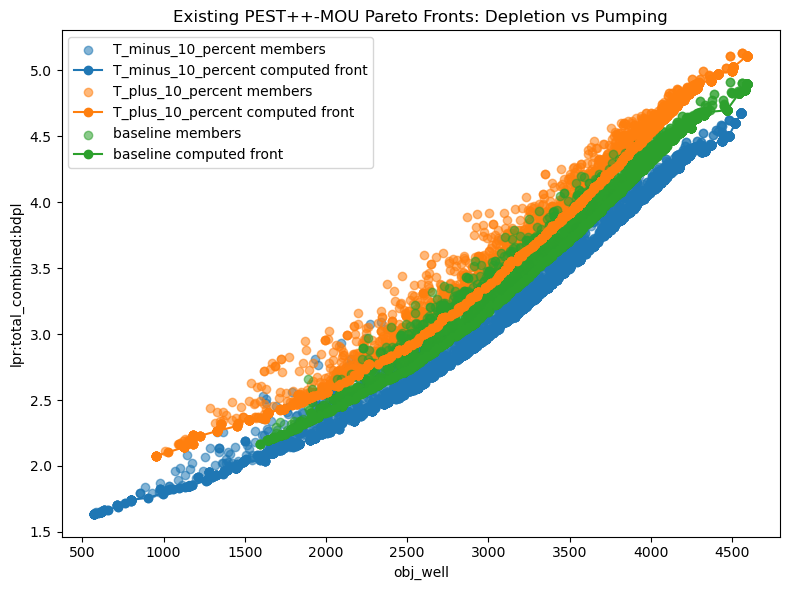

Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/existing_depletion_q_pareto_fronts.png


In [148]:
plt.figure(figsize=(8, 6))

for run_case, group in combined_fronts.groupby("run_case"):
    group = group.sort_values(PUMPING_COL)
    plt.scatter(group[PUMPING_COL], group[DEPLETION_COL], alpha=0.55, label=f"{run_case} members")

    nd = group[group["computed_nondominated"]].sort_values(PUMPING_COL)
    if len(nd) > 0:
        plt.plot(nd[PUMPING_COL], nd[DEPLETION_COL], marker="o", label=f"{run_case} computed front")

plt.xlabel(PUMPING_COL)
plt.ylabel(DEPLETION_COL)
plt.title("Existing PEST++-MOU Pareto Fronts: Depletion vs Pumping")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "existing_depletion_q_pareto_fronts.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 11. Load the Pareto-member pumping table

This table should contain the pumping decisions for baseline Pareto members.

The notebook will try to match its columns to PyCAP wells.


In [149]:
pareto_members_q_path = PARETO_DEPLETION_DIR / "depletion_q_baseline_0.0_1.0_0.2_pareto_members_q.csv"

pareto_members_q = pd.read_csv(pareto_members_q_path)

pareto_members_q_preview_path = TABLES_DIR / "pareto_members_q_preview.csv"
pareto_members_q.head(20).to_csv(pareto_members_q_preview_path, index=False)

print(f"Pareto member pumping table shape: {pareto_members_q.shape}")
print(f"Saved preview: {pareto_members_q_preview_path.relative_to(PROJECT_ROOT)}")
pareto_members_q.head()


Pareto member pumping table shape: (179, 328)
Saved preview: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_members_q_preview.csv


,Unnamed: 0,well_1013__q,well_1302__q,well_1323__q,well_1486__q,well_1584__q,well_1589__q,well_1643__q,well_1683__q,well_1860__q,...,well_93143__q,well_93349__q,well_93422__q,well_93423__q,well_93424__q,well_93469__q,well_93832__q,well_94302__q,well_94988__q,well_95068__q
0,10,125.1,88.2,76.2,222.8,150.5,264.1,114.5,260.6,195.7,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
1,gen=49_member=1825_pso,125.1,88.2,76.2,222.8,150.5,264.1,114.5,260.6,195.7,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
2,12,125.1,88.2,76.2,222.8,150.5,264.1,114.5,260.6,195.7,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
3,36,125.1,88.2,76.2,222.8,150.5,264.1,114.5,260.6,195.7,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
4,gen=43_member=1604_pso,125.1,88.2,76.2,222.8,150.5,264.1,114.5,260.6,195.7,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3


In [150]:
pareto_members_q.dtypes.to_frame("dtype").head(50)


,dtype
Unnamed: 0,object
well_1013__q,float64
well_1302__q,float64
well_1323__q,float64
well_1486__q,float64
well_1584__q,float64
well_1589__q,float64
well_1643__q,float64
well_1683__q,float64
well_1860__q,float64


## 12. Load PyCAP baseline well information and individual-well DP tables

The member-level reevaluation below uses linear superposition:

$$
\text{member depletion} = \sum_i Q_{i,\text{member}} \times DP_i
$$

where:

- $Q_{i,\text{member}}$ is the pumping assigned to well $i$ for a Pareto member
- $DP_i$ is the individual-well depletion potential from PyCAP for the chosen scenario

This is the key bridge between the Pareto-member pumping table and the PyCAP uncertainty results.


In [151]:
GPM_TO_CFS = 1 / 7.48052 / 60

with open(PYCAP_YAML_PATH, "r") as f:
    pycap_config = yaml.safe_load(f)


def is_likely_well_entry(key, value):
    if not isinstance(value, dict):
        return False
    key_text = str(key).lower()
    has_q = "Q" in value or "q" in value
    has_loc = isinstance(value.get("loc"), dict)
    key_says_well = "well" in key_text
    return key_says_well and (has_q or has_loc)


def build_well_inventory(config):
    rows = []
    for key, value in config.items():
        if not is_likely_well_entry(key, value):
            continue

        loc = value.get("loc", {})
        q_gpm = value.get("Q", value.get("q", np.nan))
        q_cfs = q_gpm * GPM_TO_CFS if pd.notna(q_gpm) else np.nan

        rows.append(
            {
                "well_key": key,
                "name": str(value.get("name", key)),
                "Q_gpm": q_gpm,
                "Q_cfs": q_cfs,
                "x": loc.get("x", np.nan) if isinstance(loc, dict) else np.nan,
                "y": loc.get("y", np.nan) if isinstance(loc, dict) else np.nan,
            }
        )
    return pd.DataFrame(rows)


baseline_wells_df = build_well_inventory(pycap_config)

baseline_dp_output_path = PYCAP_BASE_OUTPUT_DIR / f"{PYCAP_RUN_NAME}.table_report.base_stream_depletion.csv"
baseline_stream_depletion = pd.read_csv(baseline_dp_output_path, index_col=0)

baseline_dp = baseline_wells_df.merge(
    baseline_stream_depletion[["LPR"]].rename(columns={"LPR": "DEPL_cfs"}),
    left_on="name",
    right_index=True,
    how="left",
)

baseline_dp["Depletion_Potential"] = baseline_dp["DEPL_cfs"] / baseline_dp["Q_cfs"]

print(f"Baseline wells: {len(baseline_wells_df)}")
baseline_dp.head()


Baseline wells: 327


,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
0,well_418,418,109.5,0.243967,89.483927,44.443073,6.689931e-03,2.742146e-02
1,well_466,466,315.9,0.703828,89.493950,44.461175,3.830911e-01,5.442964e-01
2,well_467,467,296.9,0.661496,89.493973,44.458573,2.874797e-01,4.345903e-01
3,well_490,490,27.7,0.061716,89.312108,44.466657,5.003177e-12,8.106795e-11
4,well_509,509,0.1,0.000223,89.471377,44.520602,2.753485e-07,1.235850e-03


In [152]:
scenario_dp_path = PARAM_PERTURB_TABLES_DIR / "all_scenarios_depletion_potential.csv"

if scenario_dp_path.exists():
    scenario_dp = pd.read_csv(scenario_dp_path)
    print(f"Loaded scenario DP table: {scenario_dp_path.relative_to(PROJECT_ROOT)}")
    print(f"Shape: {scenario_dp.shape}")
else:
    print(f"Scenario DP table not found: {scenario_dp_path.relative_to(PROJECT_ROOT)}")
    print("Using baseline DP only.")
    scenario_dp = baseline_dp.copy()
    scenario_dp.insert(0, "scenario", "baseline")
    scenario_dp.insert(1, "parameter", "none")
    scenario_dp.insert(2, "factor", 1.0)

scenario_dp.head()


Loaded scenario DP table: results/pycap_runs/parameter_perturbation/tables/all_scenarios_depletion_potential.csv
Shape: (2289, 11)


,scenario,parameter,factor,well_key,name,Q_gpm,Q_cfs,x,y,DEPL_cfs,Depletion_Potential
0,baseline,none,1.0,well_418,418,109.5,0.243967,89.483927,44.443073,6.689931e-03,2.742146e-02
1,baseline,none,1.0,well_466,466,315.9,0.703828,89.493950,44.461175,3.830911e-01,5.442964e-01
2,baseline,none,1.0,well_467,467,296.9,0.661496,89.493973,44.458573,2.874797e-01,4.345903e-01
3,baseline,none,1.0,well_490,490,27.7,0.061716,89.312108,44.466657,5.003177e-12,8.106795e-11
4,baseline,none,1.0,well_509,509,0.1,0.000223,89.471377,44.520602,2.753485e-07,1.235850e-03


## 13. Match Pareto pumping columns to PyCAP wells

This step is important and may require manual review.

The notebook tries to match Pareto-member pumping columns to PyCAP wells using either:

- `well_key`, such as `well_23627`
- `name`, such as `23627`


In [153]:
import re

def clean_pareto_well_column(col):
    """
    Convert Pareto decision-variable column names to PyCAP well keys.

    Example:
    'well_1013__q' -> 'well_1013'
    """
    col = str(col)

    match = re.match(r"^(well_\d+)__q$", col)
    if match:
        return match.group(1)

    return None


# Candidate numeric columns in the Pareto-member table.
q_numeric_cols = pareto_members_q.select_dtypes(include=[np.number]).columns.tolist()

# Remove index-like columns
q_numeric_cols = [
    col for col in q_numeric_cols
    if not str(col).lower().startswith("unnamed")
]

# Build lookup table for PyCAP wells.
baseline_wells_df = baseline_wells_df.copy()
baseline_wells_df["well_key_str"] = baseline_wells_df["well_key"].astype(str)
baseline_wells_df["name_str"] = baseline_wells_df["name"].astype(str)

well_lookup_by_key = baseline_wells_df.set_index("well_key_str").to_dict(orient="index")

matched_rows = []
unmatched_numeric_cols = []

for col in q_numeric_cols:
    pareto_well_key = clean_pareto_well_column(col)

    if pareto_well_key in well_lookup_by_key:
        well_info = well_lookup_by_key[pareto_well_key]

        matched_rows.append(
            {
                "pareto_column": col,
                "match_type": "well_key_from_pareto_q_column",
                "well_key": pareto_well_key,
                "name": str(well_info["name"]),
                "baseline_Q_gpm": well_info["Q_gpm"],
                "baseline_Q_cfs": well_info["Q_cfs"],
            }
        )
    else:
        unmatched_numeric_cols.append(col)

matched_well_columns = pd.DataFrame(matched_rows)

matched_well_columns_path = TABLES_DIR / "matched_pareto_pumping_columns_to_pycap_wells.csv"
matched_well_columns.to_csv(matched_well_columns_path, index=False)

print(f"Numeric Pareto columns checked: {len(q_numeric_cols)}")
print(f"Matched well pumping columns: {len(matched_well_columns)}")
print(f"Unmatched numeric columns: {len(unmatched_numeric_cols)}")
print(f"Saved: {matched_well_columns_path.relative_to(PROJECT_ROOT)}")

display(matched_well_columns.head(20))

print("\nFirst 50 unmatched numeric columns:")
for col in unmatched_numeric_cols[:50]:
    print(repr(col))

Numeric Pareto columns checked: 327
Matched well pumping columns: 327
Unmatched numeric columns: 0
Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/matched_pareto_pumping_columns_to_pycap_wells.csv


,pareto_column,match_type,well_key,name,baseline_Q_gpm,baseline_Q_cfs
0,well_1013__q,well_key_from_pareto_q_column,well_1013,1013,125.1,0.278724
1,well_1302__q,well_key_from_pareto_q_column,well_1302,1302,88.2,0.196510
2,well_1323__q,well_key_from_pareto_q_column,well_1323,1323,76.2,0.169774
3,well_1486__q,well_key_from_pareto_q_column,well_1486,1486,222.8,0.496400
4,well_1584__q,well_key_from_pareto_q_column,well_1584,1584,150.5,0.335315
5,well_1589__q,well_key_from_pareto_q_column,well_1589,1589,264.1,0.588417
6,well_1643__q,well_key_from_pareto_q_column,well_1643,1643,114.5,0.255107
7,well_1683__q,well_key_from_pareto_q_column,well_1683,1683,260.6,0.580619
8,well_1860__q,well_key_from_pareto_q_column,well_1860,1860,195.7,0.436021
9,well_23610__q,well_key_from_pareto_q_column,well_23610,23610,201.7,0.449389



First 50 unmatched numeric columns:


In [154]:
unmatched_numeric_cols[:50]


[]

## 14. Infer pumping units in the Pareto-member pumping table

The Pareto-member table could store pumping as:

1. actual cfs,
2. gpm, or
3. fraction of baseline pumping.

This cell estimates the most plausible interpretation.

You can manually override with:

```python
PARETO_Q_UNIT_MODE = "cfs"       # use values as cfs
PARETO_Q_UNIT_MODE = "gpm"       # convert values from gpm to cfs
PARETO_Q_UNIT_MODE = "fraction"  # multiply values by baseline Q_cfs
```


In [155]:
# Set to "auto", "cfs", "gpm", or "fraction".
PARETO_Q_UNIT_MODE = "auto"

if matched_well_columns.empty:
    raise ValueError(
        "No Pareto pumping columns matched PyCAP wells. "
        "Review the Pareto-member pumping table and matching logic."
    )

matched_cols = matched_well_columns["pareto_column"].tolist()

q_values = pareto_members_q[matched_cols].to_numpy(dtype=float)
q_min = np.nanmin(q_values)
q_max = np.nanmax(q_values)
q_mean = np.nanmean(q_values)

print(f"Pareto-member pumping values over matched columns:")
print(f"  min  = {q_min:.6g}")
print(f"  mean = {q_mean:.6g}")
print(f"  max  = {q_max:.6g}")

if PARETO_Q_UNIT_MODE == "auto":
    if q_max > 20:
        inferred_mode = "gpm"
    elif q_max <= 1.05 and q_min >= 0:
        inferred_mode = "fraction"
    else:
        inferred_mode = "cfs"
else:
    inferred_mode = PARETO_Q_UNIT_MODE

print(f"Using Pareto Q unit mode: {inferred_mode}")


Pareto-member pumping values over matched columns:
  min  = 0
  mean = 156.504
  max  = 1133.7
Using Pareto Q unit mode: gpm


In [156]:
def get_member_pumping_cfs_matrix(pareto_q_df, matched_cols_df, unit_mode):
    """Return member pumping matrix in cfs and well metadata in the same column order."""
    cols = matched_cols_df["pareto_column"].tolist()
    values = pareto_q_df[cols].to_numpy(dtype=float)

    baseline_q_cfs = matched_cols_df["baseline_Q_cfs"].to_numpy(dtype=float)

    if unit_mode == "cfs":
        q_cfs = values
    elif unit_mode == "gpm":
        q_cfs = values * GPM_TO_CFS
    elif unit_mode == "fraction":
        q_cfs = values * baseline_q_cfs
    else:
        raise ValueError("unit_mode must be one of: cfs, gpm, fraction")

    return q_cfs, matched_cols_df.copy()


member_q_cfs_matrix, member_well_metadata = get_member_pumping_cfs_matrix(
    pareto_members_q,
    matched_well_columns,
    inferred_mode,
)

member_total_pumping_cfs = member_q_cfs_matrix.sum(axis=1)

member_pumping_summary = pd.DataFrame(
    {
        "member_row": np.arange(len(pareto_members_q)),
        "member_total_pumping_cfs": member_total_pumping_cfs,
        "member_total_pumping_mgd": member_total_pumping_cfs * 7.48052 * 60 * 60 * 24 / 1_000_000,
    }
)

member_pumping_summary_path = TABLES_DIR / "pareto_member_total_pumping_summary.csv"
member_pumping_summary.to_csv(member_pumping_summary_path, index=False)

print(f"Saved: {member_pumping_summary_path.relative_to(PROJECT_ROOT)}")
member_pumping_summary.describe()


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_member_total_pumping_summary.csv


,member_row,member_total_pumping_cfs,member_total_pumping_mgd
count,179.000000,179.000000,179.000000
mean,89.000000,114.022090,73.694407
std,51.816986,1.691780,1.093426
min,0.000000,110.410617,71.360251
25%,44.500000,112.781833,72.892808
50%,89.000000,114.390616,73.932591
75%,133.500000,115.375243,74.568973
max,178.000000,117.088200,75.676086


## 15. Reevaluate Pareto members under PyCAP uncertainty scenarios

For each scenario from notebook `04`, we estimate member-level depletion using:

$$
D_m = \sum_i Q_{m,i} DP_{s,i}
$$

where:

- $D_m$ = total stream depletion for Pareto member $m$
- $Q_{m,i}$ = pumping for member $m$ at well $i$
- $DP_{s,i}$ = depletion potential for well $i$ under scenario $s$

This lets us ask how each existing Pareto member performs under PyCAP uncertainty scenarios.


In [157]:
# Build well order for member pumping matrix.
member_well_keys = member_well_metadata["well_key"].astype(str).tolist()

member_results_rows = []

for scenario, group in scenario_dp.groupby("scenario"):
    group = group.copy()
    group["well_key"] = group["well_key"].astype(str)

    dp_lookup = group.set_index("well_key")["Depletion_Potential"].to_dict()

    # Align DP vector to the matched Pareto pumping columns.
    dp_vector = np.array([dp_lookup.get(well_key, np.nan) for well_key in member_well_keys], dtype=float)

    if np.isnan(dp_vector).any():
        missing_count = int(np.isnan(dp_vector).sum())
        print(f"Warning: {scenario} has {missing_count} missing DP values for matched Pareto wells.")
        dp_vector = np.nan_to_num(dp_vector, nan=0.0)

    member_depletion_cfs = member_q_cfs_matrix @ dp_vector
    member_streamflow_cfs = BASELINE_HOOVER_STREAMFLOW_CFS - member_depletion_cfs

    parameter = group["parameter"].iloc[0] if "parameter" in group.columns else "unknown"
    factor = group["factor"].iloc[0] if "factor" in group.columns else np.nan

    for i in range(len(pareto_members_q)):
        member_results_rows.append(
            {
                "scenario": scenario,
                "parameter": parameter,
                "factor": factor,
                "member_row": i,
                "member_total_pumping_cfs": member_total_pumping_cfs[i],
                "member_total_depletion_cfs": member_depletion_cfs[i],
                "member_streamflow_cfs": member_streamflow_cfs[i],
                "meets_prf": member_streamflow_cfs[i] >= PUBLIC_RIGHTS_FLOW_CFS,
                "excess_depletion_over_prf_cfs": max(0.0, member_depletion_cfs[i] - PRF_ALLOWED_DEPLETION_CFS),
            }
        )

member_uncertainty_results = pd.DataFrame(member_results_rows)

member_uncertainty_results_path = TABLES_DIR / "pareto_member_uncertainty_reevaluation.csv"
member_uncertainty_results.to_csv(member_uncertainty_results_path, index=False)

print(f"Saved: {member_uncertainty_results_path.relative_to(PROJECT_ROOT)}")
member_uncertainty_results.head()


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_member_uncertainty_reevaluation.csv


,scenario,parameter,factor,member_row,member_total_pumping_cfs,member_total_depletion_cfs,member_streamflow_cfs,meets_prf,excess_depletion_over_prf_cfs
0,Q_high_110,Q,1.1,0,117.088200,5.341206,3.258794,False,3.541206
1,Q_high_110,Q,1.1,1,110.410617,2.463450,6.136550,False,0.663450
2,Q_high_110,Q,1.1,2,116.988363,5.272150,3.327850,False,3.472150
3,Q_high_110,Q,1.1,3,116.815648,5.138037,3.461963,False,3.338037
4,Q_high_110,Q,1.1,4,113.745998,3.641327,4.958673,False,1.841327


## 16. Summarize Pareto-member robustness

A robust member should maintain acceptable streamflow across uncertainty scenarios.

Here, robustness is evaluated using the public-rights-flow threshold:

```text
streamflow >= 6.8 cfs
```


In [158]:
member_robustness = (
    member_uncertainty_results
    .groupby("member_row", as_index=False)
    .agg(
        member_total_pumping_cfs=("member_total_pumping_cfs", "first"),
        streamflow_min=("member_streamflow_cfs", "min"),
        streamflow_mean=("member_streamflow_cfs", "mean"),
        streamflow_max=("member_streamflow_cfs", "max"),
        depletion_min=("member_total_depletion_cfs", "min"),
        depletion_mean=("member_total_depletion_cfs", "mean"),
        depletion_max=("member_total_depletion_cfs", "max"),
        prf_success_count=("meets_prf", "sum"),
        n_scenarios=("meets_prf", "size"),
        max_excess_depletion_over_prf_cfs=("excess_depletion_over_prf_cfs", "max"),
    )
)

member_robustness["prf_success_fraction"] = (
    member_robustness["prf_success_count"] / member_robustness["n_scenarios"]
)

member_robustness["robust_meets_prf_all_scenarios"] = (
    member_robustness["prf_success_fraction"] == 1.0
)

member_robustness_path = TABLES_DIR / "pareto_member_robustness_summary.csv"
member_robustness.to_csv(member_robustness_path, index=False)

print(f"Saved: {member_robustness_path.relative_to(PROJECT_ROOT)}")
member_robustness.head()


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_member_robustness_summary.csv


,member_row,member_total_pumping_cfs,streamflow_min,streamflow_mean,streamflow_max,depletion_min,depletion_mean,depletion_max,prf_success_count,n_scenarios,max_excess_depletion_over_prf_cfs,prf_success_fraction,robust_meets_prf_all_scenarios
0,0,117.088200,2.965015,3.256301,3.542990,5.057010,5.343699,5.634985,0,7,3.834985,0.0,False
1,1,110.410617,5.941233,6.133799,6.321275,2.278725,2.466201,2.658767,0,7,0.858767,0.0,False
2,2,116.988363,3.034969,3.325359,3.611153,4.988847,5.274641,5.565031,0,7,3.765031,0.0,False
3,3,116.815648,3.172235,3.459405,3.741853,4.858147,5.140595,5.427765,0,7,3.627765,0.0,False
4,4,113.745998,4.714820,4.955982,5.192166,3.407834,3.644018,3.885180,0,7,2.085180,0.0,False


In [159]:
robustness_overview = pd.DataFrame(
    [
        {
            "metric": "number_of_members",
            "value": len(member_robustness),
        },
        {
            "metric": "members_meeting_prf_all_scenarios",
            "value": int(member_robustness["robust_meets_prf_all_scenarios"].sum()),
        },
        {
            "metric": "members_failing_prf_at_least_once",
            "value": int((~member_robustness["robust_meets_prf_all_scenarios"]).sum()),
        },
        {
            "metric": "max_member_total_pumping_cfs_among_robust",
            "value": member_robustness.loc[
                member_robustness["robust_meets_prf_all_scenarios"],
                "member_total_pumping_cfs",
            ].max(),
        },
        {
            "metric": "max_member_total_pumping_cfs_overall",
            "value": member_robustness["member_total_pumping_cfs"].max(),
        },
    ]
)

robustness_overview_path = TABLES_DIR / "pareto_member_robustness_overview.csv"
robustness_overview.to_csv(robustness_overview_path, index=False)

print(f"Saved: {robustness_overview_path.relative_to(PROJECT_ROOT)}")
robustness_overview


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_member_robustness_overview.csv


,metric,value
0,number_of_members,179.0000
1,members_meeting_prf_all_scenarios,0.0000
2,members_failing_prf_at_least_once,179.0000
3,max_member_total_pumping_cfs_among_robust,NaN
4,max_member_total_pumping_cfs_overall,117.0882


## 17. Plot member streamflow uncertainty versus pumping

This plot is one of the most useful links between Pareto optimization and uncertainty analysis.

Each member has a range of possible streamflow values across the uncertainty scenarios.


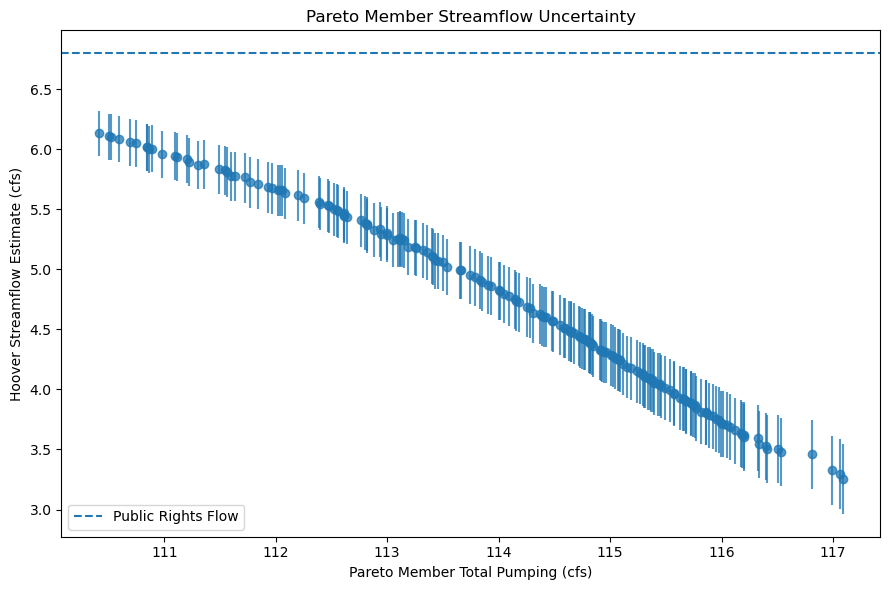

Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/pareto_member_streamflow_uncertainty_vs_pumping.png


In [160]:
plot_df = member_robustness.sort_values("member_total_pumping_cfs").copy()

plt.figure(figsize=(9, 6))

plt.errorbar(
    plot_df["member_total_pumping_cfs"],
    plot_df["streamflow_mean"],
    yerr=[
        plot_df["streamflow_mean"] - plot_df["streamflow_min"],
        plot_df["streamflow_max"] - plot_df["streamflow_mean"],
    ],
    fmt="o",
    alpha=0.75,
)

plt.axhline(PUBLIC_RIGHTS_FLOW_CFS, linestyle="--", label="Public Rights Flow")
plt.xlabel("Pareto Member Total Pumping (cfs)")
plt.ylabel("Hoover Streamflow Estimate (cfs)")
plt.title("Pareto Member Streamflow Uncertainty")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "pareto_member_streamflow_uncertainty_vs_pumping.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 18. Plot member depletion uncertainty versus pumping

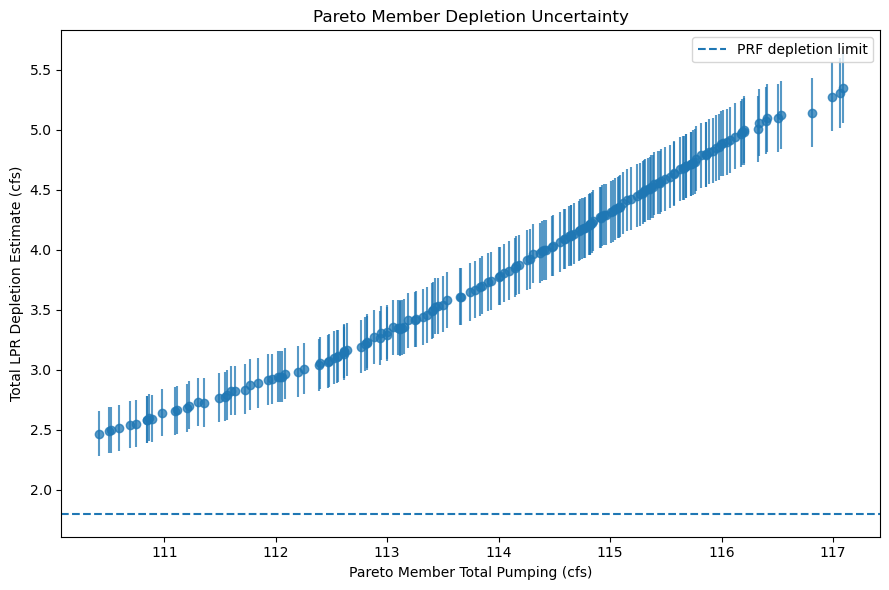

Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/pareto_member_depletion_uncertainty_vs_pumping.png


In [161]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    plot_df["member_total_pumping_cfs"],
    plot_df["depletion_mean"],
    yerr=[
        plot_df["depletion_mean"] - plot_df["depletion_min"],
        plot_df["depletion_max"] - plot_df["depletion_mean"],
    ],
    fmt="o",
    alpha=0.75,
)

plt.axhline(PRF_ALLOWED_DEPLETION_CFS, linestyle="--", label="PRF depletion limit")
plt.xlabel("Pareto Member Total Pumping (cfs)")
plt.ylabel("Total LPR Depletion Estimate (cfs)")
plt.title("Pareto Member Depletion Uncertainty")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "pareto_member_depletion_uncertainty_vs_pumping.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")


## 19. Compare deterministic uncertainty scenarios for Pareto members

This table shows how the PRF success count changes by scenario.


In [162]:
scenario_member_summary = (
    member_uncertainty_results
    .groupby(["scenario", "parameter", "factor"], as_index=False)
    .agg(
        n_members=("member_row", "size"),
        members_meeting_prf=("meets_prf", "sum"),
        min_streamflow=("member_streamflow_cfs", "min"),
        mean_streamflow=("member_streamflow_cfs", "mean"),
        max_streamflow=("member_streamflow_cfs", "max"),
        min_depletion=("member_total_depletion_cfs", "min"),
        mean_depletion=("member_total_depletion_cfs", "mean"),
        max_depletion=("member_total_depletion_cfs", "max"),
    )
)

scenario_member_summary["fraction_members_meeting_prf"] = (
    scenario_member_summary["members_meeting_prf"] / scenario_member_summary["n_members"]
)

scenario_member_summary_path = TABLES_DIR / "pareto_member_summary_by_uncertainty_scenario.csv"
scenario_member_summary.to_csv(scenario_member_summary_path, index=False)

print(f"Saved: {scenario_member_summary_path.relative_to(PROJECT_ROOT)}")
scenario_member_summary


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_member_summary_by_uncertainty_scenario.csv


,scenario,parameter,factor,n_members,members_meeting_prf,min_streamflow,mean_streamflow,max_streamflow,min_depletion,mean_depletion,max_depletion,fraction_members_meeting_prf
0,Q_high_110,Q,1.1,179,0,3.258794,4.728861,6.136550,2.463450,3.871139,5.341206,0.0
1,Q_low_90,Q,0.9,179,0,3.258794,4.728861,6.136550,2.463450,3.871139,5.341206,0.0
2,S_high_110,S,1.1,179,0,3.516268,4.944220,6.304118,2.295882,3.655780,5.083732,0.0
3,S_low_90,S,0.9,179,0,2.965015,4.481081,5.941233,2.658767,4.118919,5.634985,0.0
4,T_high_110,T,1.1,179,0,2.993453,4.505152,5.960313,2.639687,4.094848,5.606547,0.0
5,T_low_90,T,0.9,179,0,3.542990,4.966445,6.321275,2.278725,3.633555,5.057010,0.0
6,baseline,none,1.0,179,0,3.258794,4.728861,6.136550,2.463450,3.871139,5.341206,0.0


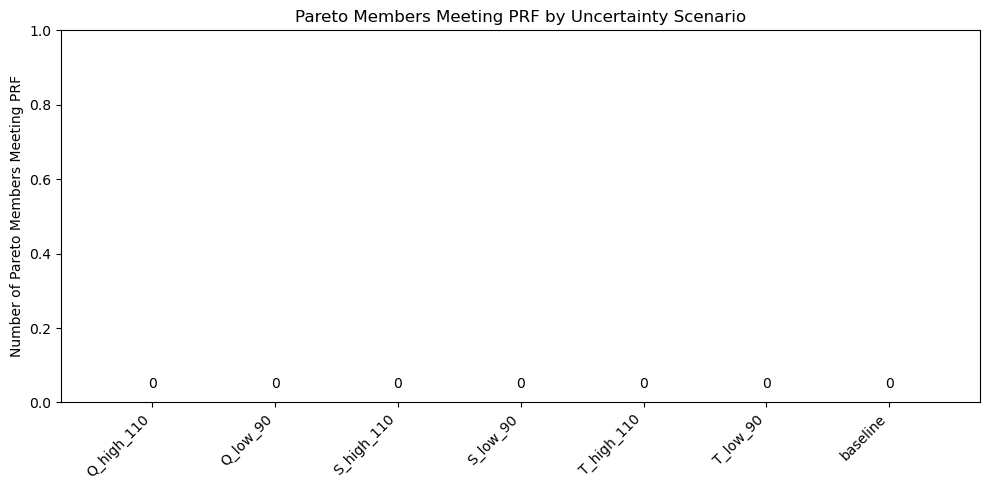

Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/pareto_member_prf_success_count_by_scenario.png


In [163]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    scenario_member_summary["scenario"],
    scenario_member_summary["members_meeting_prf"],
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Pareto Members Meeting PRF")
plt.title("Pareto Members Meeting PRF by Uncertainty Scenario")

# Make zero-result plot readable
plt.ylim(0, max(1, scenario_member_summary["members_meeting_prf"].max() + 1))

for bar, value in zip(bars, scenario_member_summary["members_meeting_prf"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        0.03,
        str(int(value)),
        ha="center",
        va="bottom",
    )

plt.tight_layout()

fig_path = FIGURES_DIR / "pareto_member_prf_success_count_by_scenario.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

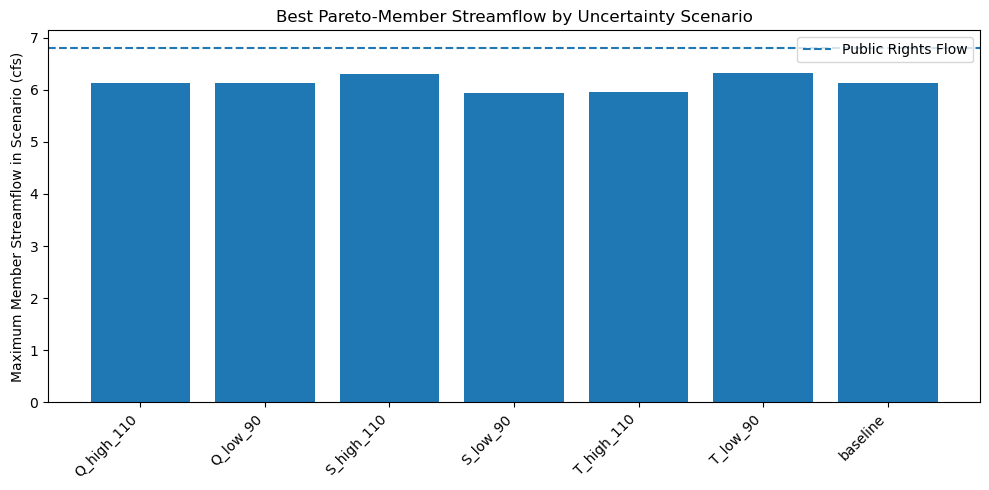

Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/best_member_streamflow_by_scenario.png


In [164]:
plt.figure(figsize=(10, 5))

plt.bar(
    scenario_member_summary["scenario"],
    scenario_member_summary["max_streamflow"],
)

plt.axhline(PUBLIC_RIGHTS_FLOW_CFS, linestyle="--", label="Public Rights Flow")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Maximum Member Streamflow in Scenario (cfs)")
plt.title("Best Pareto-Member Streamflow by Uncertainty Scenario")
plt.legend()
plt.tight_layout()

fig_path = FIGURES_DIR / "best_member_streamflow_by_scenario.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

In [165]:
n_robust = int(member_robustness["robust_meets_prf_all_scenarios"].sum())

if n_robust > 0:
    max_robust_pumping = member_robustness.loc[
        member_robustness["robust_meets_prf_all_scenarios"],
        "member_total_pumping_cfs",
    ].max()
    max_robust_text = f"Maximum robust pumping = {max_robust_pumping:.3f} cfs."
    max_robust_interpretation = "This is a useful candidate metric for uncertainty-aware decision support."
else:
    max_robust_text = "No Pareto members met PRF in all tested uncertainty scenarios."
    max_robust_interpretation = (
        "Under the current PRF calculation, all imported Pareto members exceed the allowed depletion threshold. "
        "This may mean the imported Pareto run used a different constraint/objective framing than the PRF threshold."
    )

## 20. Optional: compare fish/dollars Pareto fronts

The fish/dollars artifacts are included, but this project may focus first on depletion-vs-pumping.

This section inventories and plots fish/dollars fronts if objective columns can be detected.


In [166]:
fish_baseline_key = "fish_dollars__baseline__pareto_summary"

if fish_baseline_key in fish_tables:
    fish_baseline = fish_tables[fish_baseline_key].copy()
    print(f"Fish/dollars baseline shape: {fish_baseline.shape}")

    fish_col = find_best_column(
        fish_baseline,
        ["fish", "trout", "likelihood", "prob"],
        exclude_keywords=["generation", "rank"],
    )
    dollars_col = find_best_column(
        fish_baseline,
        ["dollar", "receipt", "ag", "economic", "revenue"],
        exclude_keywords=["generation", "rank"],
    )

    print(f"Auto fish column: {fish_col}")
    print(f"Auto dollars column: {dollars_col}")

    display(fish_baseline.head())
else:
    print("No fish/dollars baseline Pareto summary table found.")
    fish_col = None
    dollars_col = None


Fish/dollars baseline shape: (2606, 10)
Auto fish column: fish_prob
Auto dollars column: ag_receipts


,generation,member,ag_receipts,fish_prob,nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,0,12356800.0,0.546370,4,1.000000e+30,9.000180,9.000180,1,-999
1,0,1,12350500.0,0.544987,5,1.000000e+30,0.000094,0.000094,1,-999
2,0,2,12362400.0,0.548751,2,1.116780e+00,23.000200,23.000200,1,-999
3,0,3,12361200.0,0.541642,3,8.019550e-01,0.000201,0.000201,1,-999
4,0,4,12319800.0,0.554410,3,1.000000e+30,0.000106,0.000106,1,-999


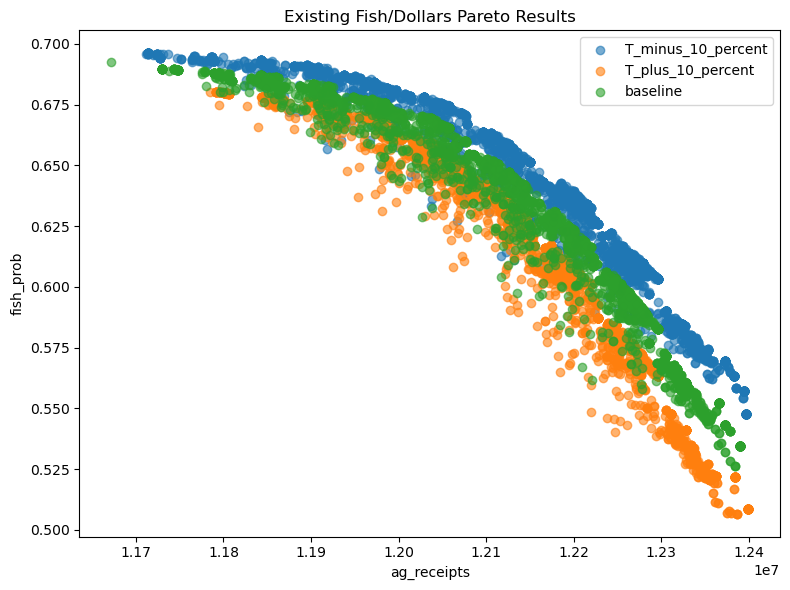

Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/combined_fish_dollars_pareto_fronts.csv
Saved: results/pycap_runs/pareto_uncertainty_comparison/figures/existing_fish_dollars_pareto_results.png


In [167]:
if fish_col is not None and dollars_col is not None:
    fish_front_keys = [
        "fish_dollars__baseline__pareto_summary",
        "fish_dollars__T_minus_10_percent__pareto_summary",
        "fish_dollars__T_plus_10_percent__pareto_summary",
    ]

    fish_front_tables = []

    for key in fish_front_keys:
        if key not in fish_tables:
            continue

        df = fish_tables[key].copy()
        family, run_case, table_type = key.split("__")
        df["family"] = family
        df["run_case"] = run_case
        fish_front_tables.append(df)

    combined_fish_fronts = pd.concat(fish_front_tables, ignore_index=True)

    fish_fronts_path = TABLES_DIR / "combined_fish_dollars_pareto_fronts.csv"
    combined_fish_fronts.to_csv(fish_fronts_path, index=False)

    plt.figure(figsize=(8, 6))
    for run_case, group in combined_fish_fronts.groupby("run_case"):
        plt.scatter(group[dollars_col], group[fish_col], alpha=0.6, label=run_case)

    plt.xlabel(dollars_col)
    plt.ylabel(fish_col)
    plt.title("Existing Fish/Dollars Pareto Results")
    plt.legend()
    plt.tight_layout()

    fig_path = FIGURES_DIR / "existing_fish_dollars_pareto_results.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print(f"Saved: {fish_fronts_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved: {fig_path.relative_to(PROJECT_ROOT)}")

else:
    print("Skipping fish/dollars plot because objective columns were not detected.")


## 21. First-pass interpretation table

This table summarizes the main results to review for your report.


In [168]:
n_robust = int(member_robustness["robust_meets_prf_all_scenarios"].sum())

if n_robust > 0:
    max_robust_pumping = member_robustness.loc[
        member_robustness["robust_meets_prf_all_scenarios"],
        "member_total_pumping_cfs",
    ].max()

    robust_pumping_finding = f"Maximum robust pumping = {max_robust_pumping:.3f} cfs."
    robust_pumping_interpretation = (
        "This is a useful candidate metric for uncertainty-aware decision support."
    )
else:
    robust_pumping_finding = (
        "No Pareto members met PRF in all tested uncertainty scenarios."
    )
    robust_pumping_interpretation = (
        "Under the current PRF calculation, all imported Pareto members exceed the "
        "allowed depletion threshold. This likely means the imported Pareto run used "
        "a different constraint/objective framing than the PRF threshold."
    )

interpretation_rows = [
    {
        "topic": "Existing Pareto artifacts",
        "finding": f"Loaded {len(depletion_tables)} depletion_q tables and {len(fish_tables)} fish_dollars tables.",
        "interpretation": "The optimized Pareto results already exist and can be analyzed without rerunning PEST++-MOU.",
    },
    {
        "topic": "Objective columns",
        "finding": f"Using {PUMPING_COL} as pumping objective and {DEPLETION_COL} as depletion objective.",
        "interpretation": "The depletion_q Pareto front is interpreted as a pumping/depletion tradeoff.",
    },
    {
        "topic": "Pareto member pumping table",
        "finding": f"Matched {len(matched_well_columns)} Pareto pumping columns to PyCAP wells using unit mode '{inferred_mode}'.",
        "interpretation": "This enables member-level uncertainty reevaluation by linear superposition.",
    },
    {
        "topic": "PRF robustness",
        "finding": f"{n_robust} of {len(member_robustness)} members meet PRF in all tested uncertainty scenarios.",
        "interpretation": (
            "Members that meet PRF in all scenarios would be more robust management alternatives. "
            "Here, none of the imported members meet that strict threshold."
        ),
    },
    {
        "topic": "Highest robust pumping",
        "finding": robust_pumping_finding,
        "interpretation": robust_pumping_interpretation,
    },
]

interpretation_table = pd.DataFrame(interpretation_rows)

interpretation_path = TABLES_DIR / "pareto_uncertainty_first_pass_interpretation.csv"
interpretation_table.to_csv(interpretation_path, index=False)

print(f"Saved: {interpretation_path.relative_to(PROJECT_ROOT)}")
interpretation_table

Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_uncertainty_first_pass_interpretation.csv


,topic,finding,interpretation
0,Existing Pareto artifacts,Loaded 9 depletion_q tables and 9 fish_dollars...,The optimized Pareto results already exist and...
1,Objective columns,Using obj_well as pumping objective and lpr:to...,The depletion_q Pareto front is interpreted as...
2,Pareto member pumping table,Matched 327 Pareto pumping columns to PyCAP we...,This enables member-level uncertainty reevalua...
3,PRF robustness,0 of 179 members meet PRF in all tested uncert...,Members that meet PRF in all scenarios would b...
4,Highest robust pumping,No Pareto members met PRF in all tested uncert...,"Under the current PRF calculation, all importe..."


## 22. Save notebook summary

In [169]:
notebook_summary = pd.DataFrame(
    [
        {"item": "project_root", "value": str(PROJECT_ROOT)},
        {"item": "pareto_raw_dir", "value": str(PARETO_RAW_DIR.relative_to(PROJECT_ROOT))},
        {"item": "output_dir", "value": str(NOTEBOOK_OUT_DIR.relative_to(PROJECT_ROOT))},
        {"item": "number_of_pareto_artifact_files", "value": len(pareto_files)},
        {"item": "number_of_depletion_tables_loaded", "value": len(depletion_tables)},
        {"item": "number_of_fish_dollars_tables_loaded", "value": len(fish_tables)},
        {"item": "pumping_objective_column", "value": PUMPING_COL},
        {"item": "depletion_objective_column", "value": DEPLETION_COL},
        {"item": "pareto_q_unit_mode", "value": inferred_mode},
        {"item": "matched_pareto_well_columns", "value": len(matched_well_columns)},
        {"item": "number_of_pareto_members", "value": len(pareto_members_q)},
        {"item": "number_of_uncertainty_scenarios_used", "value": member_uncertainty_results["scenario"].nunique()},
        {"item": "baseline_hoover_streamflow_cfs", "value": BASELINE_HOOVER_STREAMFLOW_CFS},
        {"item": "public_rights_flow_cfs", "value": PUBLIC_RIGHTS_FLOW_CFS},
        {"item": "allowed_depletion_cfs", "value": PRF_ALLOWED_DEPLETION_CFS},
        {"item": "run_timestamp", "value": datetime.now().isoformat(timespec="seconds")},
    ]
)

notebook_summary_path = TABLES_DIR / "pareto_uncertainty_notebook_summary.csv"
notebook_summary.to_csv(notebook_summary_path, index=False)

print(f"Saved: {notebook_summary_path.relative_to(PROJECT_ROOT)}")
notebook_summary


Saved: results/pycap_runs/pareto_uncertainty_comparison/tables/pareto_uncertainty_notebook_summary.csv


,item,value
0,project_root,/workspaces/Modeling-Uncertainties
1,pareto_raw_dir,data/raw/lpr_pycap/pareto
2,output_dir,results/pycap_runs/pareto_uncertainty_comparison
3,number_of_pareto_artifact_files,22
4,number_of_depletion_tables_loaded,9
5,number_of_fish_dollars_tables_loaded,9
6,pumping_objective_column,obj_well
7,depletion_objective_column,lpr:total_combined:bdpl
8,pareto_q_unit_mode,gpm
9,matched_pareto_well_columns,327


## 23. Final interpretation

This notebook connects three major pieces of the project:

1. **Existing PEST++-MOU Pareto optimization results**
2. **PyCAP individual-well depletion potential**
3. **Uncertainty scenarios from notebooks 04/05**

The strongest outputs to review are:

```text
pareto_member_robustness_summary.csv
pareto_member_summary_by_uncertainty_scenario.csv
pareto_member_streamflow_uncertainty_vs_pumping.png
pareto_member_depletion_uncertainty_vs_pumping.png
existing_depletion_q_pareto_fronts.png
```

A good next notebook is:

```text
06b_pycap_uncertainty_report_figures.ipynb
```

That notebook should create clean, presentation-ready figures from notebooks 04, 05a, 05b, and 06a.
